In [13]:
!pip install -q pandas numpy scipy matplotlib seaborn scikit-learn xgboost imbalanced-learn openpyxl joblib plotly

In [14]:
import os
import warnings
import urllib.request
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    f1_score,
    matthews_corrcoef,
    roc_auc_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, IsolationForest
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.inspection import permutation_importance

from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

os.makedirs("data/nhanes", exist_ok=True)
os.makedirs("data/dryad", exist_ok=True)
os.makedirs("output", exist_ok=True)

CLASS_ORDER = ["Hypotensive", "Normal", "Hypertensive"]
CLASS_TO_ID = {c: i for i, c in enumerate(CLASS_ORDER)}
ID_TO_CLASS = {i: c for c, i in CLASS_TO_ID.items()}

In [15]:
NHANES_FILES = {
    "BPXO_L.XPT": "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/BPXO_L.XPT",
    "DEMO_L.XPT": "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/DEMO_L.XPT",
    "BMX_L.XPT": "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/BMX_L.XPT",
    "RXQ_RX_L.XPT": "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/RXQ_RX_L.XPT",
}

for fname, url in NHANES_FILES.items():
    dest = os.path.join("data/nhanes", fname)
    if not os.path.exists(dest):
        print(f"Downloading {fname}...")
        urllib.request.urlretrieve(url, dest)
        print(f"Saved to {dest}")
    else:
        print(f"Already exists: {dest}")

DRYAD_XLSX_PATH = "data/dryad/Blood_Pressure_Sleep_Info.xlsx"
DRYAD_INFO_CSV = "data/dryad/Participant_Information.csv"

print("Dryad Excel exists:", os.path.exists(DRYAD_XLSX_PATH))
print("Dryad participant CSV exists:", os.path.exists(DRYAD_INFO_CSV))

Already exists: data/nhanes/BPXO_L.XPT
Already exists: data/nhanes/DEMO_L.XPT
Already exists: data/nhanes/BMX_L.XPT
Already exists: data/nhanes/RXQ_RX_L.XPT
Dryad Excel exists: True
Dryad participant CSV exists: False


In [16]:
def decode_object_columns(df):
    df = df.copy()
    for col in df.columns:
        if df[col].dtype == object:
            df[col] = df[col].apply(
                lambda x: x.decode("latin1").strip() if isinstance(x, (bytes, bytearray)) else x
            )
    return df

def find_col(columns, keywords):
    lowered = {c: str(c).lower() for c in columns}
    for col, low in lowered.items():
        if any(k in low for k in keywords):
            return col
    return None

def describe_df(df, name):
    print(f"\n{name}")
    print("-" * len(name))
    print("Shape:", df.shape)
    print("Duplicate rows:", df.duplicated().sum())
    print("Top missing %:")
    print((df.isna().mean().sort_values(ascending=False).head(15) * 100).round(2))

def class_specificity(cm):
    out = {}
    total = cm.sum()
    for i in range(cm.shape[0]):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        tn = total - tp - fn - fp
        out[i] = tn / (tn + fp + 1e-9)
    return out

def evaluate_multiclass(model_name, y_true, y_pred, y_prob=None, class_order=None):
    metrics = {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
        "mcc": matthews_corrcoef(y_true, y_pred),
    }

    p_macro, r_macro, f_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    metrics["macro_precision"] = p_macro
    metrics["macro_recall"] = r_macro

    cm = confusion_matrix(y_true, y_pred, labels=range(len(class_order)))
    spec = class_specificity(cm)

    per_class_rows = []
    for i, cls in enumerate(class_order):
        tp = cm[i, i]
        support = cm[i, :].sum()
        pred_support = cm[:, i].sum()
        recall_i = tp / support if support else 0.0
        precision_i = tp / pred_support if pred_support else 0.0
        per_class_rows.append({
            "class": cls,
            "support": int(support),
            "precision": precision_i,
            "recall": recall_i,
            "specificity": spec[i]
        })
        slug = cls.lower()
        metrics[f"recall_{slug}"] = recall_i
        metrics[f"specificity_{slug}"] = spec[i]

    if y_prob is not None:
        y_true_ohe = pd.get_dummies(y_true).reindex(columns=range(len(class_order)), fill_value=0)
        try:
            metrics["roc_auc_ovr_macro"] = roc_auc_score(
                y_true_ohe, y_prob, multi_class="ovr", average="macro"
            )
        except Exception:
            metrics["roc_auc_ovr_macro"] = np.nan
    else:
        metrics["roc_auc_ovr_macro"] = np.nan

    return metrics, cm, pd.DataFrame(per_class_rows)

def plot_cm(cm, class_order, title):
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_order, yticklabels=class_order)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

def second_reading_rule(sbp, dbp):
    if pd.isna(sbp) or pd.isna(dbp):
        return "Normal"
    if sbp < 90 or dbp < 60:
        return "Hypotensive"
    elif sbp >= 130 or dbp >= 80:
        return "Hypertensive"
    else:
        return "Normal"

In [17]:
df_bp = decode_object_columns(pd.read_sas("data/nhanes/BPXO_L.XPT", format="xport", encoding="latin1"))
df_rx = decode_object_columns(pd.read_sas("data/nhanes/RXQ_RX_L.XPT", format="xport", encoding="latin1"))
df_demo = decode_object_columns(pd.read_sas("data/nhanes/DEMO_L.XPT", format="xport", encoding="latin1"))
df_bmx = decode_object_columns(pd.read_sas("data/nhanes/BMX_L.XPT", format="xport", encoding="latin1"))

bp_cols = [
    "SEQN", "BPXOSY1", "BPXOSY2", "BPXOSY3",
    "BPXODI1", "BPXODI2", "BPXODI3",
    "BPXOPLS1", "BPXOPLS2", "BPXOPLS3"
]
demo_cols = ["SEQN", "RIDAGEYR", "RIAGENDR", "RIDRETH3", "INDFMPIR", "DMDEDUC2", "RIDEXPRG"]
bmx_cols = ["SEQN", "BMXBMI", "BMXWT", "BMXHT"]

df_bp = df_bp[[c for c in bp_cols if c in df_bp.columns]].copy()
df_demo = df_demo[[c for c in demo_cols if c in df_demo.columns]].copy()
df_bmx = df_bmx[[c for c in bmx_cols if c in df_bmx.columns]].copy()

rx_cols = ["SEQN"] + [c for c in ["RXDUSE", "RXDCOUNT", "RXQ050", "RXQ033"] if c in df_rx.columns]
df_rx_sub = df_rx[rx_cols].copy()

if "RXDUSE" in df_rx_sub.columns:
    df_rx_sub["antihypertensive_flag"] = (
        pd.to_numeric(df_rx_sub["RXDUSE"], errors="coerce") == 1
    ).astype(int)
else:
    df_rx_sub["antihypertensive_flag"] = 0

if "RXDCOUNT" in df_rx_sub.columns:
    df_rx_sub["rx_count"] = pd.to_numeric(df_rx_sub["RXDCOUNT"], errors="coerce")
elif "RXQ050" in df_rx_sub.columns:
    df_rx_sub["rx_count"] = pd.to_numeric(df_rx_sub["RXQ050"], errors="coerce")
else:
    df_rx_sub["rx_count"] = np.nan

df_rx_sub["rx_count"] = df_rx_sub["rx_count"].fillna(0)

df_meds = (
    df_rx_sub.groupby("SEQN", as_index=False)
    .agg(
        antihypertensive_flag=("antihypertensive_flag", "max"),
        rx_count=("rx_count", "max")
    )
)

df = (
    df_bp
    .merge(df_demo, on="SEQN", how="left")
    .merge(df_bmx, on="SEQN", how="left")
    .merge(df_meds, on="SEQN", how="left")
)

df["antihypertensive_flag"] = df["antihypertensive_flag"].fillna(0).astype(int)
df["rx_count"] = df["rx_count"].fillna(0)

describe_df(df, "Merged NHANES dataframe")
display(df.head())


Merged NHANES dataframe
-----------------------
Shape: (7801, 21)
Duplicate rows: 0
Top missing %:
RIDEXPRG    85.46
DMDEDUC2    22.27
INDFMPIR    12.82
BPXODI3      4.11
BPXOSY3      4.11
BPXOPLS3     4.11
BPXOPLS2     3.79
BPXODI2      3.79
BPXOSY2      3.79
BPXOSY1      3.64
BPXODI1      3.64
BPXOPLS1     3.64
BMXBMI       1.41
BMXWT        1.22
BMXHT        1.05
dtype: float64


,SEQN,BPXOSY1,BPXOSY2,BPXOSY3,BPXODI1,BPXODI2,BPXODI3,BPXOPLS1,BPXOPLS2,BPXOPLS3,...,RIAGENDR,RIDRETH3,INDFMPIR,DMDEDUC2,RIDEXPRG,BMXBMI,BMXWT,BMXHT,antihypertensive_flag,rx_count
0,130378.0,135.0,131.0,132.0,98.0,96.0,94.0,82.0,79.0,82.0,...,1.0,6.0,5.00,5.0,NaN,27.0,86.9,179.5,0,1.0
1,130379.0,121.0,117.0,113.0,84.0,76.0,76.0,72.0,71.0,73.0,...,1.0,3.0,5.00,5.0,NaN,33.5,101.8,174.2,0,1.0
2,130380.0,111.0,112.0,104.0,79.0,80.0,76.0,84.0,83.0,77.0,...,2.0,2.0,1.41,3.0,2.0,29.7,69.4,152.9,0,1.0
3,130386.0,110.0,120.0,115.0,72.0,74.0,75.0,59.0,64.0,64.0,...,1.0,1.0,1.33,4.0,NaN,30.2,90.6,173.3,0,0.0
4,130387.0,143.0,136.0,145.0,76.0,74.0,78.0,80.0,80.0,77.0,...,2.0,3.0,1.32,5.0,NaN,42.6,103.5,155.9,0,1.0


In [18]:
DRYAD_STATS = {
    "mean_sys_std": 8.0,
    "mean_sys_range": 20.0,
    "mean_morning_evening_diff": 5.0,
    "nondipper_prevalence": 0.30
}

df_dryad = None
dryad_subject = None

if os.path.exists(DRYAD_XLSX_PATH):
    xl = pd.ExcelFile(DRYAD_XLSX_PATH)
    dryad_frames = []
    for sheet in xl.sheet_names:
        tmp = xl.parse(sheet)
        tmp["sheet_name"] = sheet
        dryad_frames.append(tmp)

    df_dryad = pd.concat(dryad_frames, ignore_index=True)
    describe_df(df_dryad, "Dryad raw combined")

    subj_col = find_col(df_dryad.columns, ["participant", "subject", "patient", "id", "pid"])
    sys_col = find_col(df_dryad.columns, ["systolic", "sbp", "sys"])
    dia_col = find_col(df_dryad.columns, ["diastolic", "dbp", "dia"])
    time_col = find_col(df_dryad.columns, ["time", "hour", "timestamp", "date"])
    sleep_col = find_col(df_dryad.columns, ["sleep", "wake", "rest", "state"])

    print("Detected Dryad columns")
    print("subject:", subj_col)
    print("systolic:", sys_col)
    print("diastolic:", dia_col)
    print("time:", time_col)
    print("sleep:", sleep_col)

    if sys_col:
        df_dryad[sys_col] = pd.to_numeric(df_dryad[sys_col], errors="coerce")
    if dia_col:
        df_dryad[dia_col] = pd.to_numeric(df_dryad[dia_col], errors="coerce")
    if time_col:
        dt = pd.to_datetime(df_dryad[time_col], errors="coerce")
        df_dryad["hour"] = dt.dt.hour

    if subj_col and sys_col:
        def summarize_subject(g):
            s = g[sys_col].dropna()
            out = {
                "dryad_sys_mean": s.mean() if len(s) else np.nan,
                "dryad_sys_std": s.std() if len(s) > 1 else np.nan,
                "dryad_sys_max": s.max() if len(s) else np.nan,
                "dryad_sys_min": s.min() if len(s) else np.nan,
                "dryad_n": len(s)
            }
            out["dryad_sys_range"] = (
                out["dryad_sys_max"] - out["dryad_sys_min"]
                if pd.notna(out["dryad_sys_max"]) and pd.notna(out["dryad_sys_min"])
                else np.nan
            )

            if "hour" in g.columns:
                morning = g.loc[g["hour"].between(6, 11, inclusive="both"), sys_col].dropna()
                evening = g.loc[g["hour"].between(18, 23, inclusive="both"), sys_col].dropna()
                out["morning_evening_diff"] = (
                    morning.mean() - evening.mean()
                    if len(morning) and len(evening) else np.nan
                )
            else:
                out["morning_evening_diff"] = np.nan

            if sleep_col and sleep_col in g.columns:
                asleep = g[sleep_col].astype(str).str.lower().str.contains("sleep|asleep|night|rest", na=False)
                night = g.loc[asleep, sys_col].dropna()
                day = g.loc[~asleep, sys_col].dropna()
                out["dipper_ratio"] = (
                    night.mean() / day.mean()
                    if len(night) and len(day) and day.mean() != 0 else np.nan
                )
            else:
                out["dipper_ratio"] = np.nan

            return pd.Series(out)

        dryad_subject = df_dryad.groupby(subj_col).apply(summarize_subject).reset_index()

        DRYAD_STATS = {
            "mean_sys_std": float(dryad_subject["dryad_sys_std"].dropna().mean()) if dryad_subject["dryad_sys_std"].notna().any() else 8.0,
            "mean_sys_range": float(dryad_subject["dryad_sys_range"].dropna().mean()) if dryad_subject["dryad_sys_range"].notna().any() else 20.0,
            "mean_morning_evening_diff": float(dryad_subject["morning_evening_diff"].dropna().mean()) if dryad_subject["morning_evening_diff"].notna().any() else 5.0,
            "nondipper_prevalence": float((dryad_subject["dipper_ratio"] >= 0.90).mean()) if dryad_subject["dipper_ratio"].notna().any() else 0.30
        }

print("DRYAD_STATS =", DRYAD_STATS)


Dryad raw combined
------------------
Shape: (1623, 10)
Duplicate rows: 5
Top missing %:
ID            0.0
Day_Date      0.0
Time          0.0
Systolic      0.0
Diastolic     0.0
MAP           0.0
PP            0.0
HR            0.0
Wake_Sleep    0.0
sheet_name    0.0
dtype: float64
Detected Dryad columns
subject: ID
systolic: Systolic
diastolic: Diastolic
time: Day_Date
sleep: Wake_Sleep
DRYAD_STATS = {'mean_sys_std': 52.67103611246707, 'mean_sys_range': 144.16666666666666, 'mean_morning_evening_diff': 5.0, 'nondipper_prevalence': 0.3}


In [19]:
df_model = df.copy()

if "RIDEXPRG" in df_model.columns:
    preg_mask = df_model["RIDEXPRG"].fillna(0) != 1
else:
    preg_mask = pd.Series(True, index=df_model.index)

required_cols = [
    "BPXOSY1", "BPXOSY2", "BPXOSY3",
    "BPXODI1", "BPXODI2", "BPXODI3",
    "BPXOPLS1", "BPXOPLS2", "BPXOPLS3",
    "RIDAGEYR"
]

mask = preg_mask.copy() & (df_model["RIDAGEYR"] >= 18)
for c in required_cols:
    mask &= df_model[c].notna()

df_model = df_model.loc[mask].copy()

# Baseline from first two readings only
df_model["sys12_mean"] = df_model[["BPXOSY1", "BPXOSY2"]].mean(axis=1)
df_model["dia12_mean"] = df_model[["BPXODI1", "BPXODI2"]].mean(axis=1)
df_model["pulse12_mean"] = df_model[["BPXOPLS1", "BPXOPLS2"]].mean(axis=1)

df_model["sys12_std"] = df_model[["BPXOSY1", "BPXOSY2"]].std(axis=1).fillna(0)
df_model["dia12_std"] = df_model[["BPXODI1", "BPXODI2"]].std(axis=1).fillna(0)
df_model["pulse12_std"] = df_model[["BPXOPLS1", "BPXOPLS2"]].std(axis=1).fillna(0)

df_model["sys_trend_21"] = df_model["BPXOSY2"] - df_model["BPXOSY1"]
df_model["dia_trend_21"] = df_model["BPXODI2"] - df_model["BPXODI1"]
df_model["pulse_trend_21"] = df_model["BPXOPLS2"] - df_model["BPXOPLS1"]

df_model["pp12"] = df_model["sys12_mean"] - df_model["dia12_mean"]
df_model["map12"] = (df_model["sys12_mean"] + 2 * df_model["dia12_mean"]) / 3
df_model["syscv12"] = (df_model["sys12_std"] / df_model["sys12_mean"].replace(0, np.nan) * 100).fillna(0)
df_model["diacv12"] = (df_model["dia12_std"] / df_model["dia12_mean"].replace(0, np.nan) * 100).fillna(0)

df_model["is_female"] = (df_model["RIAGENDR"] == 2).astype(int)
df_model["low_income_flag"] = (df_model["INDFMPIR"] < 1.3).astype(int)

df_model["obesity_cat"] = pd.cut(
    df_model["BMXBMI"],
    bins=[0, 18.5, 25, 30, 35, 100],
    labels=["Underweight", "Normal", "Overweight", "Obese_I", "Obese_II"]
)

# Dryad-informed proxy features from first two readings only
age_med = df_model["RIDAGEYR"].median()
age_sd = df_model["RIDAGEYR"].std() + 1e-9
bmi_med = df_model["BMXBMI"].median()
bmi_sd = df_model["BMXBMI"].std() + 1e-9
std_med = df_model["sys12_std"].median()
std_sd = df_model["sys12_std"].std() + 1e-9

df_model["age_z"] = (df_model["RIDAGEYR"].fillna(age_med) - age_med) / age_sd
df_model["bmi_z"] = (df_model["BMXBMI"].fillna(bmi_med) - bmi_med) / bmi_sd
df_model["sys12_std_z"] = (df_model["sys12_std"].fillna(std_med) - std_med) / std_sd

df_model["morningsurge_proxy"] = DRYAD_STATS["mean_morning_evening_diff"] * (
    0.40 * df_model["age_z"].clip(-3, 3) +
    0.30 * df_model["bmi_z"].clip(-3, 3) +
    0.30 * df_model["sys12_std_z"].clip(-3, 3)
)

df_model["nondipper_risk"] = (
    0.35 * (df_model["sys12_mean"] >= 130).astype(int) +
    0.25 * (df_model["dia12_mean"] >= 80).astype(int) +
    0.20 * (df_model["RIDRETH3"] == 4).fillna(False).astype(int) +
    0.10 * df_model["age_z"].clip(-3, 3) +
    0.10 * (1 - df_model["antihypertensive_flag"])
)

df_model["circadian_dysregulation_index"] = (
    0.5 * df_model["syscv12"] +
    0.3 * df_model["diacv12"] +
    0.2 * df_model["nondipper_risk"]
)

SYS_FLOOR = max(5.0, DRYAD_STATS["mean_sys_std"] * 0.35)
DIA_FLOOR = 4.0

def make_personalized_alert_type(row):
    sbp3 = row["BPXOSY3"]
    dbp3 = row["BPXODI3"]

    sys_scale = max(row["sys12_std"], SYS_FLOOR)
    dia_scale = max(row["dia12_std"], DIA_FLOOR)

    z_sys = (sbp3 - row["sys12_mean"]) / (sys_scale + 1e-9)
    z_dia = (dbp3 - row["dia12_mean"]) / (dia_scale + 1e-9)

    # low alert
    if (
        (sbp3 < 90) or (dbp3 < 60) or
        (((sbp3 < 100) or (dbp3 < 65)) and ((z_sys <= -1.0) or (z_dia <= -1.0)))
    ):
        return "Hypotensive"

    # high alert
    if (
        (sbp3 >= 140) or (dbp3 >= 90) or
        (((sbp3 >= 130) or (dbp3 >= 80)) and ((z_sys >= 1.0) or (z_dia >= 1.0)))
    ):
        return "Hypertensive"

    return "Normal"

df_model["alert_type"] = df_model.apply(make_personalized_alert_type, axis=1)
df_model["alert_type"] = pd.Categorical(df_model["alert_type"], categories=CLASS_ORDER, ordered=True)
df_model["alert_type_id"] = df_model["alert_type"].map(CLASS_TO_ID).astype(int)

print("Model dataframe shape:", df_model.shape)
print(df_model["alert_type"].value_counts(dropna=False))
display(df_model.head())

Model dataframe shape: (6061, 45)
alert_type
Normal          4242
Hypertensive    1230
Hypotensive      589
Name: count, dtype: int64


,SEQN,BPXOSY1,BPXOSY2,BPXOSY3,BPXODI1,BPXODI2,BPXODI3,BPXOPLS1,BPXOPLS2,BPXOPLS3,...,low_income_flag,obesity_cat,age_z,bmi_z,sys12_std_z,morningsurge_proxy,nondipper_risk,circadian_dysregulation_index,alert_type,alert_type_id
0,130378.0,135.0,131.0,132.0,98.0,96.0,94.0,82.0,79.0,82.0,...,0,Overweight,-0.716148,-0.180939,0.000000,-1.703703,0.628385,1.626381,Hypertensive,2
1,130379.0,121.0,117.0,113.0,84.0,76.0,76.0,72.0,71.0,73.0,...,0,Obese_I,0.550883,0.723756,0.000000,2.187399,0.405088,3.390753,Normal,1
2,130380.0,111.0,112.0,104.0,79.0,80.0,76.0,84.0,83.0,77.0,...,0,Overweight,-0.661059,0.194857,-0.661968,-2.022784,0.033894,0.590700,Normal,1
3,130386.0,110.0,120.0,115.0,72.0,74.0,75.0,59.0,64.0,64.0,...,0,Obese_I,-1.211942,0.264449,1.323936,-0.041307,-0.021194,3.651322,Normal,1
4,130387.0,143.0,136.0,145.0,76.0,74.0,78.0,80.0,80.0,77.0,...,0,Obese_II,0.661059,1.990328,0.661968,5.300562,0.516106,2.443010,Hypertensive,2



NHANES modeling dataframe
-------------------------
Shape: (6061, 45)
Duplicate rows: 0
Top missing %:
RIDEXPRG       82.96
INDFMPIR       12.92
DMDEDUC2        4.26
BMXBMI          1.01
obesity_cat     1.01
BMXWT           0.79
BMXHT           0.66
BPXODI2         0.00
SEQN            0.00
BPXOSY1         0.00
BPXOSY2         0.00
BPXOSY3         0.00
BPXODI1         0.00
RIDRETH3        0.00
RIAGENDR        0.00
dtype: float64


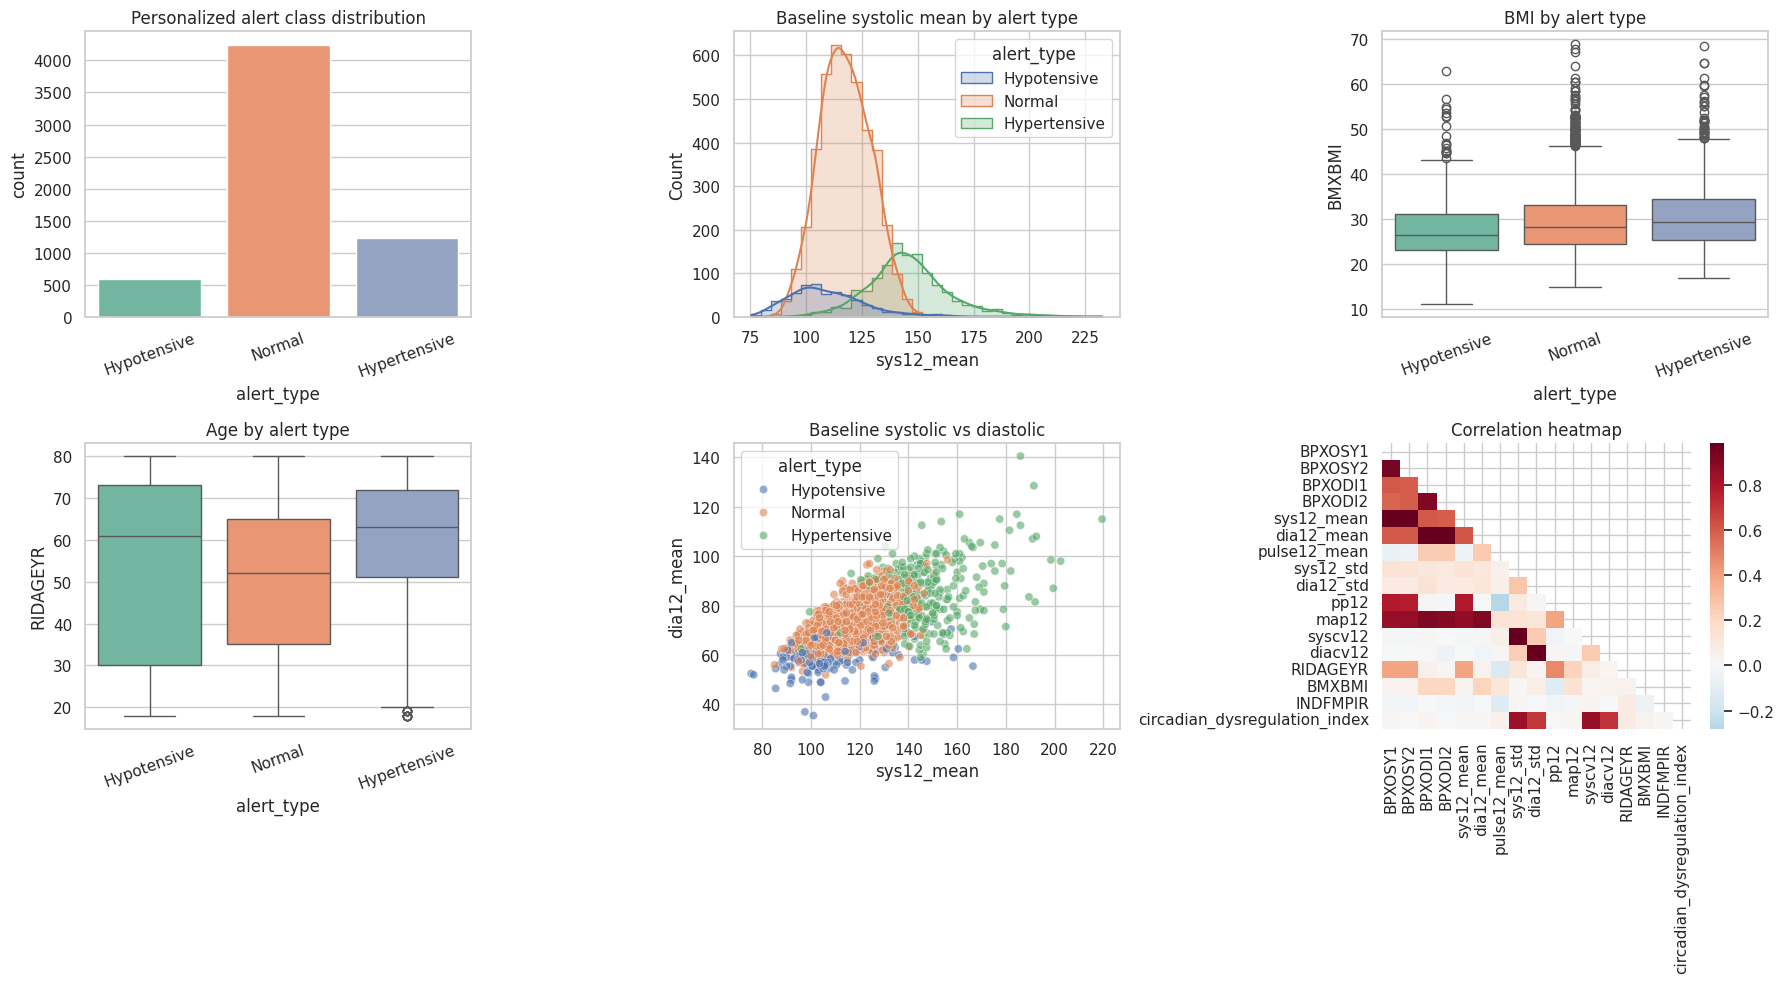

In [20]:
describe_df(df_model, "NHANES modeling dataframe")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

sns.countplot(data=df_model, x="alert_type", order=CLASS_ORDER, palette="Set2", ax=axes[0, 0])
axes[0, 0].set_title("Personalized alert class distribution")
axes[0, 0].tick_params(axis="x", rotation=20)

sns.histplot(
    data=df_model,
    x="sys12_mean",
    hue="alert_type",
    hue_order=CLASS_ORDER,
    bins=35,
    kde=True,
    element="step",
    ax=axes[0, 1]
)
axes[0, 1].set_title("Baseline systolic mean by alert type")

sns.boxplot(
    data=df_model,
    x="alert_type",
    y="BMXBMI",
    order=CLASS_ORDER,
    palette="Set2",
    ax=axes[0, 2]
)
axes[0, 2].set_title("BMI by alert type")
axes[0, 2].tick_params(axis="x", rotation=20)

sns.boxplot(
    data=df_model,
    x="alert_type",
    y="RIDAGEYR",
    order=CLASS_ORDER,
    palette="Set2",
    ax=axes[1, 0]
)
axes[1, 0].set_title("Age by alert type")
axes[1, 0].tick_params(axis="x", rotation=20)

sns.scatterplot(
    data=df_model.sample(min(1500, len(df_model)), random_state=RANDOM_STATE),
    x="sys12_mean",
    y="dia12_mean",
    hue="alert_type",
    hue_order=CLASS_ORDER,
    alpha=0.6,
    ax=axes[1, 1]
)
axes[1, 1].set_title("Baseline systolic vs diastolic")

corr_cols = [
    "BPXOSY1", "BPXOSY2", "BPXODI1", "BPXODI2",
    "sys12_mean", "dia12_mean", "pulse12_mean",
    "sys12_std", "dia12_std", "pp12", "map12",
    "syscv12", "diacv12", "RIDAGEYR", "BMXBMI",
    "INDFMPIR", "circadian_dysregulation_index"
]
corr = df_model[corr_cols].corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="RdBu_r", center=0, ax=axes[1, 2])
axes[1, 2].set_title("Correlation heatmap")

plt.tight_layout()
plt.savefig("output/nhanes_eda_multiclass.png", dpi=160, bbox_inches="tight")
plt.show()

sample_df = df_model.sample(min(1500, len(df_model)), random_state=RANDOM_STATE)
fig = px.scatter_3d(
    sample_df,
    x="sys12_mean",
    y="dia12_mean",
    z="circadian_dysregulation_index",
    color="alert_type",
    category_orders={"alert_type": CLASS_ORDER},
    size="RIDAGEYR",
    hover_data=["BPXOSY3", "BPXODI3", "BMXBMI", "sys12_std", "dia12_std"],
    title="NHANES 3D view of personalized alert types"
)
fig.show()

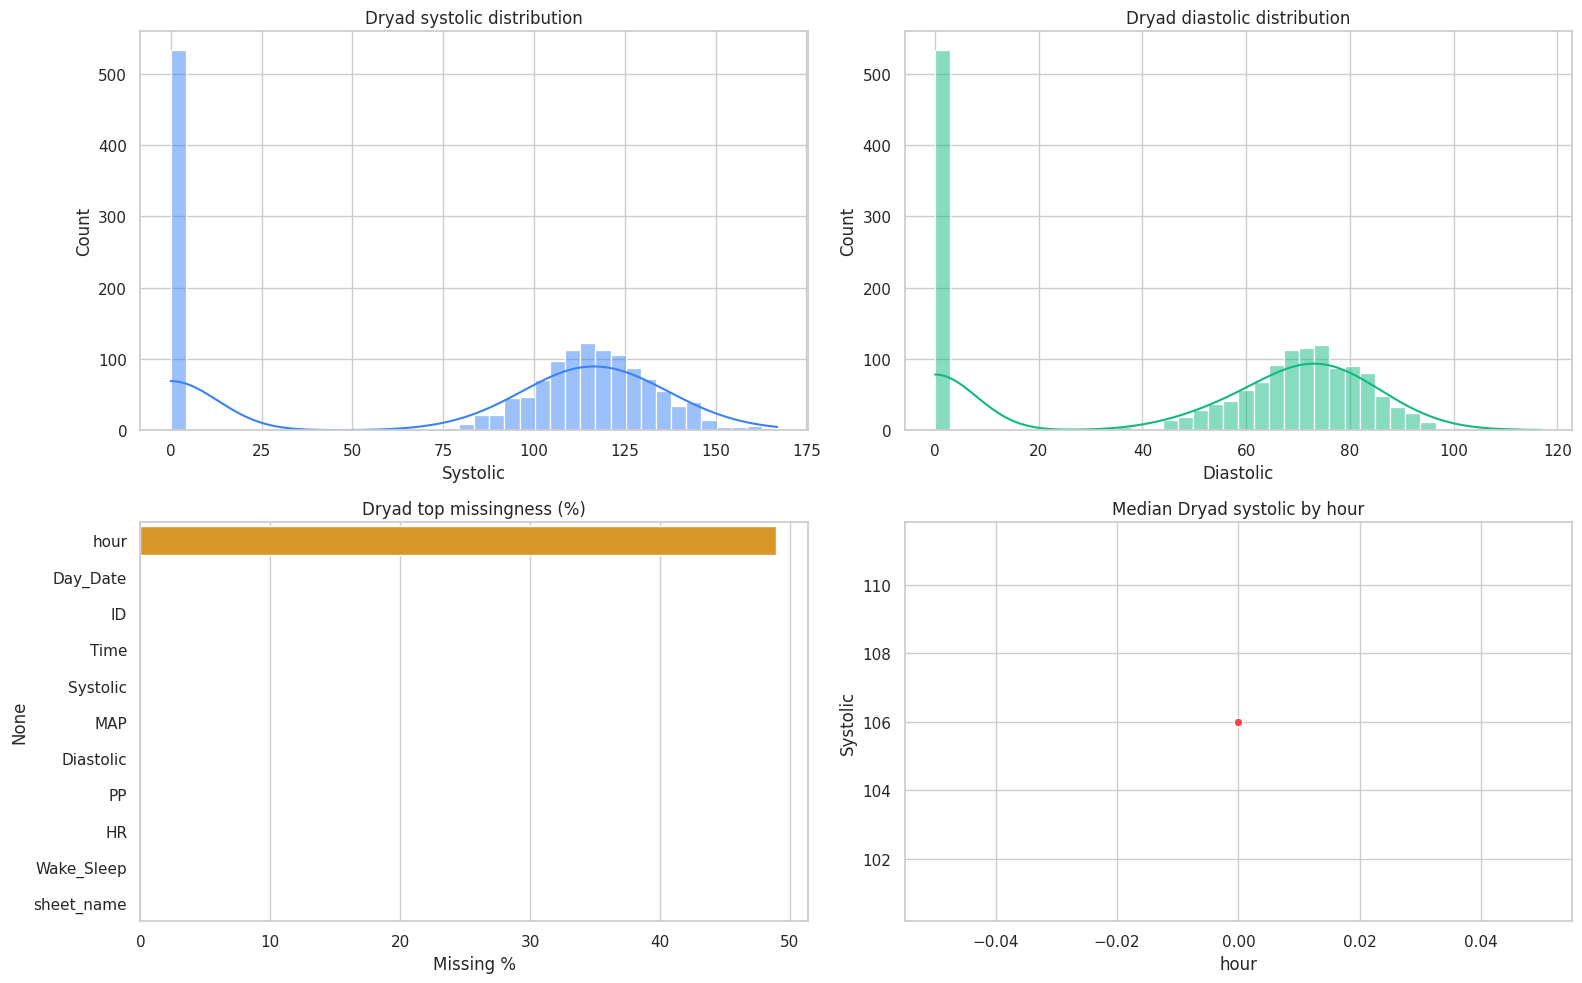

In [21]:
if df_dryad is not None:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    if sys_col:
        sns.histplot(df_dryad[sys_col].dropna(), bins=40, kde=True, ax=axes[0, 0], color="#3b82f6")
        axes[0, 0].set_title("Dryad systolic distribution")
    else:
        axes[0, 0].axis("off")

    if dia_col:
        sns.histplot(df_dryad[dia_col].dropna(), bins=40, kde=True, ax=axes[0, 1], color="#10b981")
        axes[0, 1].set_title("Dryad diastolic distribution")
    else:
        axes[0, 1].axis("off")

    miss = (df_dryad.isna().mean().sort_values(ascending=False).head(12) * 100)
    sns.barplot(x=miss.values, y=miss.index, ax=axes[1, 0], color="#f59e0b")
    axes[1, 0].set_title("Dryad top missingness (%)")
    axes[1, 0].set_xlabel("Missing %")

    if "hour" in df_dryad.columns and sys_col:
        hourly = df_dryad.groupby("hour")[sys_col].median().reset_index()
        sns.lineplot(data=hourly, x="hour", y=sys_col, marker="o", ax=axes[1, 1], color="#ef4444")
        axes[1, 1].set_title("Median Dryad systolic by hour")
    else:
        axes[1, 1].axis("off")

    plt.tight_layout()
    plt.savefig("output/dryad_eda.png", dpi=160, bbox_inches="tight")
    plt.show()

    if dryad_subject is not None:
        fig = px.scatter_3d(
            dryad_subject.dropna().sample(min(len(dryad_subject.dropna()), 1000), random_state=RANDOM_STATE),
            x="dryad_sys_mean",
            y="dryad_sys_std",
            z="dryad_sys_range",
            color="dryad_n",
            hover_data=["morning_evening_diff", "dipper_ratio"],
            title="Dryad subject-level 3D BP variability"
        )
        fig.show()
else:
    print("Dryad workbook not found, so Dryad EDA is skipped.")

In [22]:
feature_cols = [
    "RIDAGEYR", "is_female", "RIDRETH3", "INDFMPIR", "DMDEDUC2",
    "BMXBMI", "BMXWT", "BMXHT",
    "rx_count", "antihypertensive_flag",
    "BPXOSY1", "BPXOSY2", "BPXODI1", "BPXODI2", "BPXOPLS1", "BPXOPLS2",
    "sys12_mean", "dia12_mean", "pulse12_mean",
    "sys12_std", "dia12_std", "pulse12_std",
    "sys_trend_21", "dia_trend_21", "pulse_trend_21",
    "pp12", "map12", "syscv12", "diacv12",
    "low_income_flag", "obesity_cat",
    "morningsurge_proxy", "nondipper_risk", "circadian_dysregulation_index"
]

feature_cols = [c for c in feature_cols if c in df_model.columns]

X = df_model[feature_cols].copy()
y = df_model["alert_type_id"].astype(int).copy()

# remove constant columns
nunique = X.nunique(dropna=False)
drop_cols = nunique[nunique <= 1].index.tolist()
X = X.drop(columns=drop_cols)

categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = [c for c in X.columns if c not in categorical_cols]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", RobustScaler())
        ]), numeric_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_cols)
    ]
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Class distribution in full data:")
print(pd.Series(y).map(ID_TO_CLASS).value_counts())
print("Dropped constant columns:", drop_cols)

Train shape: (4848, 33)
Test shape: (1213, 33)
Class distribution in full data:
alert_type_id
Normal          4242
Hypertensive    1230
Hypotensive      589
Name: count, dtype: int64
Dropped constant columns: ['antihypertensive_flag']


In [23]:
class_counts = pd.Series(y_train).value_counts().sort_index()
class_weights = class_counts.max() / class_counts
sample_weight_train = pd.Series(y_train).map(class_weights).values

models = {
    "LogisticRegression": LogisticRegression(
        max_iter=4000,
        class_weight="balanced",
        multi_class="multinomial",
        random_state=RANDOM_STATE
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=500,
        min_samples_leaf=3,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "ExtraTrees": ExtraTreesClassifier(
        n_estimators=500,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=500,
        max_depth=4,
        learning_rate=0.04,
        subsample=0.85,
        colsample_bytree=0.85,
        min_child_weight=3,
        reg_alpha=0.2,
        reg_lambda=1.0,
        objective="multi:softprob",
        num_class=len(CLASS_ORDER),
        eval_metric="mlogloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []

for name, model in models.items():
    pipe = Pipeline([
        ("prep", preprocessor),
        ("model", model)
    ])

    scores = cross_validate(
        pipe, X_train, y_train, cv=cv,
        scoring={
            "accuracy": "accuracy",
            "balanced_accuracy": "balanced_accuracy",
            "f1_macro": "f1_macro",
            "f1_weighted": "f1_weighted",
            "precision_macro": "precision_macro",
            "recall_macro": "recall_macro"
        },
        n_jobs=-1
    )

    cv_rows.append({
        "model": name,
        "cv_accuracy": scores["test_accuracy"].mean(),
        "cv_balanced_accuracy": scores["test_balanced_accuracy"].mean(),
        "cv_macro_f1": scores["test_f1_macro"].mean(),
        "cv_weighted_f1": scores["test_f1_weighted"].mean(),
        "cv_macro_precision": scores["test_precision_macro"].mean(),
        "cv_macro_recall": scores["test_recall_macro"].mean()
    })

cv_df = pd.DataFrame(cv_rows).sort_values(["cv_macro_f1", "cv_balanced_accuracy"], ascending=False)
display(cv_df)

,model,cv_accuracy,cv_balanced_accuracy,cv_macro_f1,cv_weighted_f1,cv_macro_precision,cv_macro_recall
1,RandomForest,0.865305,0.772455,0.790704,0.862800,0.815355,0.772455
2,ExtraTrees,0.864068,0.765554,0.787577,0.860965,0.819032,0.765554
3,XGBoost,0.862007,0.740012,0.776565,0.856282,0.831901,0.740012
0,LogisticRegression,0.743607,0.782847,0.686132,0.759580,0.653797,0.782847


,model,accuracy,balanced_accuracy,macro_f1,weighted_f1,mcc,macro_precision,macro_recall,recall_hypotensive,specificity_hypotensive,recall_normal,specificity_normal,recall_hypertensive,specificity_hypertensive,roc_auc_ovr_macro
2,ExtraTrees,0.849959,0.765811,0.782005,0.847867,0.664668,0.800611,0.765811,0.661017,0.975342,0.912839,0.714286,0.723577,0.947260,0.925888
1,RandomForest,0.849134,0.764911,0.780848,0.847146,0.663243,0.799220,0.764911,0.652542,0.975342,0.910483,0.714286,0.731707,0.946225,0.926854
3,XGBoost,0.826876,0.778073,0.762503,0.828817,0.633834,0.748965,0.778073,0.711864,0.955251,0.862191,0.752747,0.760163,0.926577,0.923890
0,LogisticRegression,0.725474,0.789467,0.675717,0.742162,0.543374,0.643906,0.789467,0.872881,0.854795,0.678445,0.862637,0.817073,0.871768,0.912142


Best supervised model: ExtraTrees

=== ExtraTrees ===


,class,support,precision,recall,specificity
0,Hypotensive,118,0.742857,0.661017,0.975342
1,Normal,849,0.881684,0.912839,0.714286
2,Hypertensive,246,0.777293,0.723577,0.947260


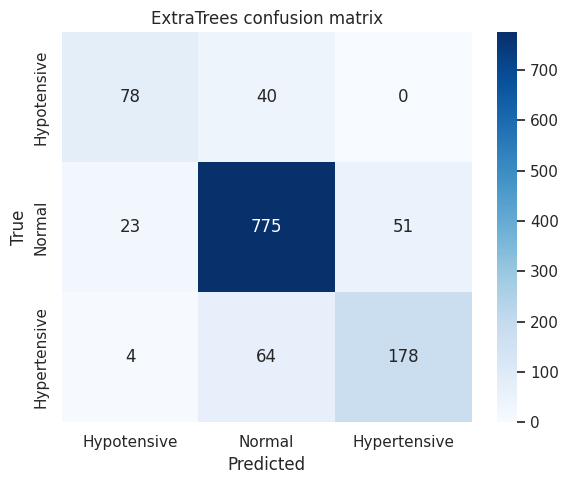


=== RandomForest ===


,class,support,precision,recall,specificity
0,Hypotensive,118,0.740385,0.652542,0.975342
1,Normal,849,0.881414,0.910483,0.714286
2,Hypertensive,246,0.775862,0.731707,0.946225


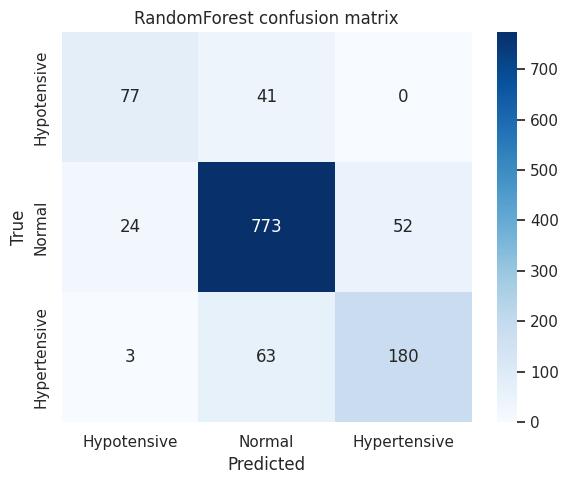


=== XGBoost ===


,class,support,precision,recall,specificity
0,Hypotensive,118,0.631579,0.711864,0.955251
1,Normal,849,0.890511,0.862191,0.752747
2,Hypertensive,246,0.724806,0.760163,0.926577


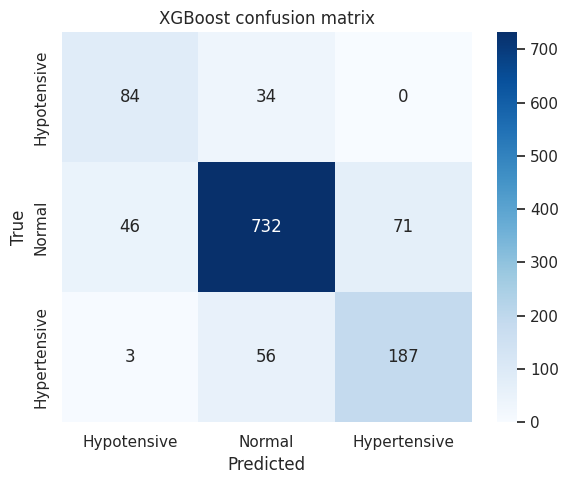


=== LogisticRegression ===


,class,support,precision,recall,specificity
0,Hypotensive,118,0.393130,0.872881,0.854795
1,Normal,849,0.920128,0.678445,0.862637
2,Hypertensive,246,0.618462,0.817073,0.871768


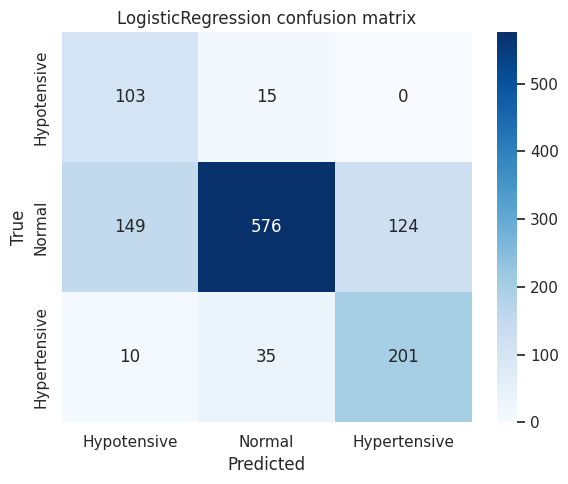

In [24]:
results = []
per_class_tables = {}
conf_mats = {}
fitted_pipelines = {}

for name, model in models.items():
    pipe = Pipeline([
        ("prep", preprocessor),
        ("model", model)
    ])

    if name == "XGBoost":
        X_train_prepared = preprocessor.fit_transform(X_train)
        X_test_prepared = preprocessor.transform(X_test)
        model.fit(X_train_prepared, y_train, sample_weight=sample_weight_train)
        y_pred = model.predict(X_test_prepared)
        y_prob = model.predict_proba(X_test_prepared)
        fitted_pipelines[name] = ("xgb_manual", model, preprocessor)
    else:
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)
        y_prob = pipe.predict_proba(X_test)
        fitted_pipelines[name] = ("pipeline", pipe)

    metrics, cm, per_class_df = evaluate_multiclass(
        name, y_test, y_pred, y_prob=y_prob, class_order=CLASS_ORDER
    )
    results.append(metrics)
    per_class_tables[name] = per_class_df
    conf_mats[name] = cm

results_df = pd.DataFrame(results).sort_values(["macro_f1", "balanced_accuracy"], ascending=False)
display(results_df)

best_model_name = results_df.iloc[0]["model"]
print("Best supervised model:", best_model_name)

for model_name in results_df["model"]:
    print(f"\n=== {model_name} ===")
    display(per_class_tables[model_name])
    plot_cm(conf_mats[model_name], CLASS_ORDER, f"{model_name} confusion matrix")

In [25]:
if best_model_name == "XGBoost":
    _, best_model, best_prep = fitted_pipelines[best_model_name]
    X_test_best = best_prep.transform(X_test)
    y_pred_best = best_model.predict(X_test_best)
    y_prob_best = best_model.predict_proba(X_test_best)
else:
    _, best_pipe = fitted_pipelines[best_model_name]
    y_pred_best = best_pipe.predict(X_test)
    y_prob_best = best_pipe.predict_proba(X_test)

print(classification_report(
    y_test,
    y_pred_best,
    target_names=CLASS_ORDER,
    digits=4
))

              precision    recall  f1-score   support

 Hypotensive     0.7429    0.6610    0.6996       118
      Normal     0.8817    0.9128    0.8970       849
Hypertensive     0.7773    0.7236    0.7495       246

    accuracy                         0.8500      1213
   macro avg     0.8006    0.7658    0.7820      1213
weighted avg     0.8470    0.8500    0.8479      1213



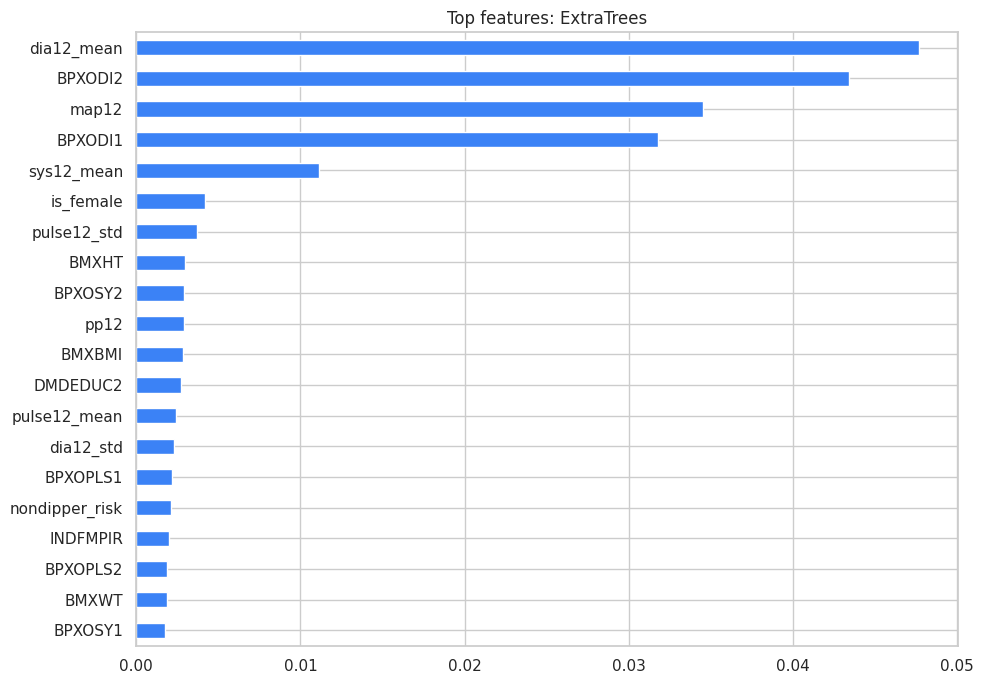

In [26]:
if best_model_name == "XGBoost":
    _, best_model, best_prep = fitted_pipelines[best_model_name]
    X_test_best = best_prep.transform(X_test)
    X_train_best = best_prep.transform(X_train)

    if hasattr(best_prep, "get_feature_names_out"):
        feature_names = best_prep.get_feature_names_out()
    else:
        feature_names = [f"f_{i}" for i in range(X_train_best.shape[1])]

    importances = pd.Series(best_model.feature_importances_, index=feature_names).sort_values().tail(20)
else:
    _, best_pipe = fitted_pipelines[best_model_name]
    perm = permutation_importance(
        best_pipe, X_test, y_test, n_repeats=10,
        random_state=RANDOM_STATE,
        scoring="f1_macro"
    )
    importances = pd.Series(perm.importances_mean, index=X_test.columns).sort_values().tail(20)

plt.figure(figsize=(10, 7))
importances.plot(kind="barh", color="#3b82f6")
plt.title(f"Top features: {best_model_name}")
plt.tight_layout()
plt.savefig("output/best_model_feature_importance.png", dpi=160, bbox_inches="tight")
plt.show()

,model,accuracy,balanced_accuracy,macro_f1,weighted_f1,mcc,macro_precision,macro_recall,recall_hypotensive,specificity_hypotensive,recall_normal,specificity_normal,recall_hypertensive,specificity_hypertensive,roc_auc_ovr_macro
0,SecondReadingRule,0.699918,0.73614,0.678372,0.714863,0.506215,0.692715,0.73614,0.635593,0.973516,0.641932,0.843407,0.930894,0.712513,0.789642


,class,support,precision,recall,specificity
0,Hypotensive,118,0.721154,0.635593,0.973516
1,Normal,849,0.905316,0.641932,0.843407
2,Hypertensive,246,0.451677,0.930894,0.712513


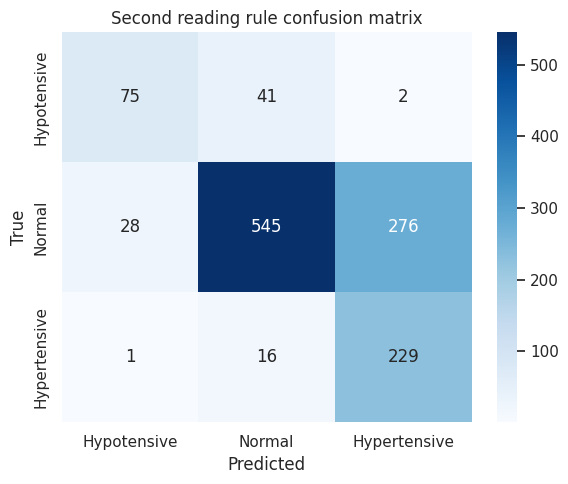

In [27]:
rule_pred = X_test.apply(
    lambda r: second_reading_rule(r["BPXOSY2"], r["BPXODI2"]),
    axis=1
).map(CLASS_TO_ID).astype(int)

rule_prob = pd.get_dummies(rule_pred).reindex(columns=range(len(CLASS_ORDER)), fill_value=0).values

rule_metrics, rule_cm, rule_per_class = evaluate_multiclass(
    "SecondReadingRule", y_test, rule_pred, y_prob=rule_prob, class_order=CLASS_ORDER
)

display(pd.DataFrame([rule_metrics]))
display(rule_per_class)
plot_cm(rule_cm, CLASS_ORDER, "Second reading rule confusion matrix")

In [29]:
unsup_features = [
    "BPXOSY1", "BPXOSY2", "BPXODI1", "BPXODI2",
    "BPXOPLS1", "BPXOPLS2",
    "sys12_mean", "dia12_mean", "pulse12_mean",
    "sys12_std", "dia12_std", "pulse12_std",
    "sys_trend_21", "dia_trend_21",
    "pp12", "map12", "syscv12", "diacv12",
    "RIDAGEYR", "BMXBMI", "INDFMPIR",
    "morningsurge_proxy", "nondipper_risk", "circadian_dysregulation_index"
]
unsup_features = [c for c in unsup_features if c in df_model.columns]

Xu = df_model[unsup_features].copy()
yu = df_model["alert_type_id"].astype(int).copy()

Xu_train, Xu_test, yu_train, yu_test = train_test_split(
    Xu, yu,
    test_size=0.20,
    stratify=yu,
    random_state=RANDOM_STATE
)

unsup_prep = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

Xu_train_scaled = unsup_prep.fit_transform(Xu_train)
Xu_test_scaled = unsup_prep.transform(Xu_test)

# Fit on all training data for clustering
kmeans = KMeans(n_clusters=3, n_init=30, random_state=RANDOM_STATE)
train_clusters = kmeans.fit_predict(Xu_train_scaled)
test_clusters = kmeans.predict(Xu_test_scaled)

cluster_map = {}
for c in np.unique(train_clusters):
    majority_class = pd.Series(yu_train.values[train_clusters == c]).mode()[0]
    cluster_map[c] = majority_class

kmeans_pred = pd.Series(test_clusters).map(cluster_map).astype(int).values

kmeans_centers = kmeans.cluster_centers_
test_dist = kmeans.transform(Xu_test_scaled).min(axis=1)

# Isolation Forest anomaly signal
normal_idx = yu_train == CLASS_TO_ID["Normal"]
iso = IsolationForest(
    n_estimators=400,
    contamination=max((yu_train != CLASS_TO_ID["Normal"]).mean(), 0.05),
    random_state=RANDOM_STATE,
    n_jobs=-1
)
iso.fit(Xu_train_scaled[normal_idx.values])
iso_score = -iso.decision_function(Xu_test_scaled)

# convert anomaly score to 3 classes with quantile bands
q_low = np.quantile(iso_score, 0.20)
q_high = np.quantile(iso_score, 0.80)

def anomaly_to_class(score):
    if score <= q_low:
        return CLASS_TO_ID["Normal"]
    elif score >= q_high:
        return CLASS_TO_ID["Hypertensive"]
    else:
        return CLASS_TO_ID["Hypotensive"]

iso_pred = np.array([anomaly_to_class(s) for s in iso_score])

,model,accuracy,balanced_accuracy,macro_f1,weighted_f1,mcc,macro_precision,macro_recall,recall_hypotensive,specificity_hypotensive,recall_normal,specificity_normal,recall_hypertensive,specificity_hypertensive,roc_auc_ovr_macro
0,KMeansClusterMap,0.731245,0.546506,0.489682,0.699987,0.419446,0.453514,0.546506,0.000000,1.000000,0.802120,0.576923,0.837398,0.822130,NaN
1,IsolationForestBanding,0.359439,0.477241,0.378004,0.421817,0.237024,0.530500,0.477241,0.627119,0.403653,0.272085,0.967033,0.532520,0.884178,NaN


,class,support,precision,recall,specificity
0,Hypotensive,118,0.000000,0.000000,1.000000
1,Normal,849,0.815569,0.802120,0.576923
2,Hypertensive,246,0.544974,0.837398,0.822130


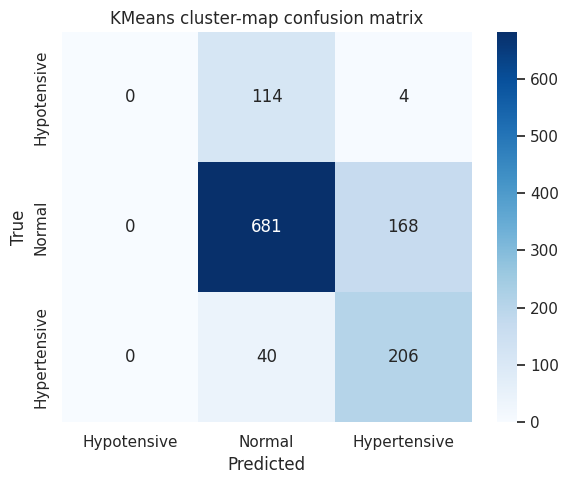

,class,support,precision,recall,specificity
0,Hypotensive,118,0.101788,0.627119,0.403653
1,Normal,849,0.950617,0.272085,0.967033
2,Hypertensive,246,0.539095,0.532520,0.884178


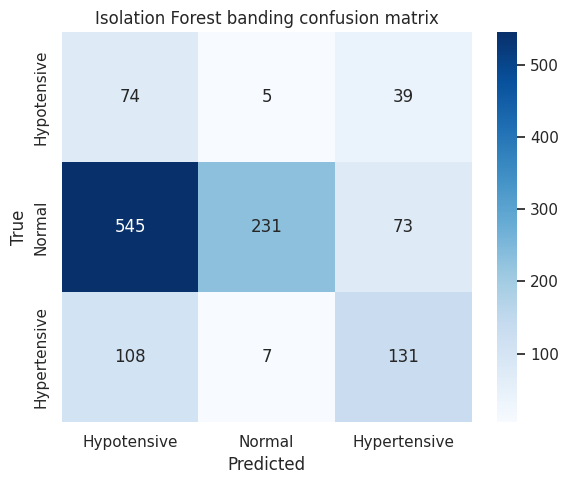

In [30]:
kmeans_metrics, kmeans_cm, kmeans_pc = evaluate_multiclass(
    "KMeansClusterMap", yu_test, kmeans_pred, y_prob=None, class_order=CLASS_ORDER
)
iso_metrics, iso_cm, iso_pc = evaluate_multiclass(
    "IsolationForestBanding", yu_test, iso_pred, y_prob=None, class_order=CLASS_ORDER
)

unsup_results_df = pd.DataFrame([kmeans_metrics, iso_metrics]).sort_values(
    ["macro_f1", "balanced_accuracy"], ascending=False
)
display(unsup_results_df)

display(kmeans_pc)
plot_cm(kmeans_cm, CLASS_ORDER, "KMeans cluster-map confusion matrix")

display(iso_pc)
plot_cm(iso_cm, CLASS_ORDER, "Isolation Forest banding confusion matrix")

In [31]:
pca = PCA(n_components=3, random_state=RANDOM_STATE)
Xu_test_pca = pca.fit_transform(Xu_test_scaled)

plot_df = pd.DataFrame(Xu_test_pca, columns=["PC1", "PC2", "PC3"], index=Xu_test.index)
plot_df["true_alert_type"] = pd.Series(yu_test, index=Xu_test.index).map(ID_TO_CLASS)
plot_df["kmeans_pred"] = pd.Series(kmeans_pred, index=Xu_test.index).map(ID_TO_CLASS)
plot_df["iso_pred"] = pd.Series(iso_pred, index=Xu_test.index).map(ID_TO_CLASS)
plot_df["iso_score"] = iso_score
plot_df["cluster_dist"] = test_dist

fig_true = px.scatter_3d(
    plot_df,
    x="PC1", y="PC2", z="PC3",
    color="true_alert_type",
    category_orders={"true_alert_type": CLASS_ORDER},
    size=np.clip(plot_df["iso_score"], 0, None) + 0.1,
    hover_data=["iso_score", "cluster_dist"],
    title="3D PCA projection colored by true alert type"
)
fig_true.show()

fig_kmeans = px.scatter_3d(
    plot_df,
    x="PC1", y="PC2", z="PC3",
    color="kmeans_pred",
    category_orders={"kmeans_pred": CLASS_ORDER},
    size=np.clip(plot_df["cluster_dist"], 0, None) + 0.1,
    hover_data=["true_alert_type", "iso_score"],
    title="3D PCA projection colored by KMeans predicted class"
)
fig_kmeans.show()

fig_iso = px.scatter_3d(
    plot_df,
    x="PC1", y="PC2", z="PC3",
    color="iso_pred",
    category_orders={"iso_pred": CLASS_ORDER},
    size=np.clip(plot_df["iso_score"], 0, None) + 0.1,
    hover_data=["true_alert_type", "cluster_dist"],
    title="3D PCA projection colored by Isolation Forest class band"
)
fig_iso.show()

,model,accuracy,balanced_accuracy,macro_f1,weighted_f1,mcc,macro_precision,macro_recall,roc_auc_ovr_macro
0,ExtraTrees,0.849959,0.765811,0.782005,0.847867,0.664668,0.800611,0.765811,0.925888
1,RandomForest,0.849134,0.764911,0.780848,0.847146,0.663243,0.799220,0.764911,0.926854
2,XGBoost,0.826876,0.778073,0.762503,0.828817,0.633834,0.748965,0.778073,0.923890
4,SecondReadingRule,0.699918,0.736140,0.678372,0.714863,0.506215,0.692715,0.736140,0.789642
3,LogisticRegression,0.725474,0.789467,0.675717,0.742162,0.543374,0.643906,0.789467,0.912142
5,KMeansClusterMap,0.731245,0.546506,0.489682,0.699987,0.419446,0.453514,0.546506,NaN
6,IsolationForestBanding,0.359439,0.477241,0.378004,0.421817,0.237024,0.530500,0.477241,NaN


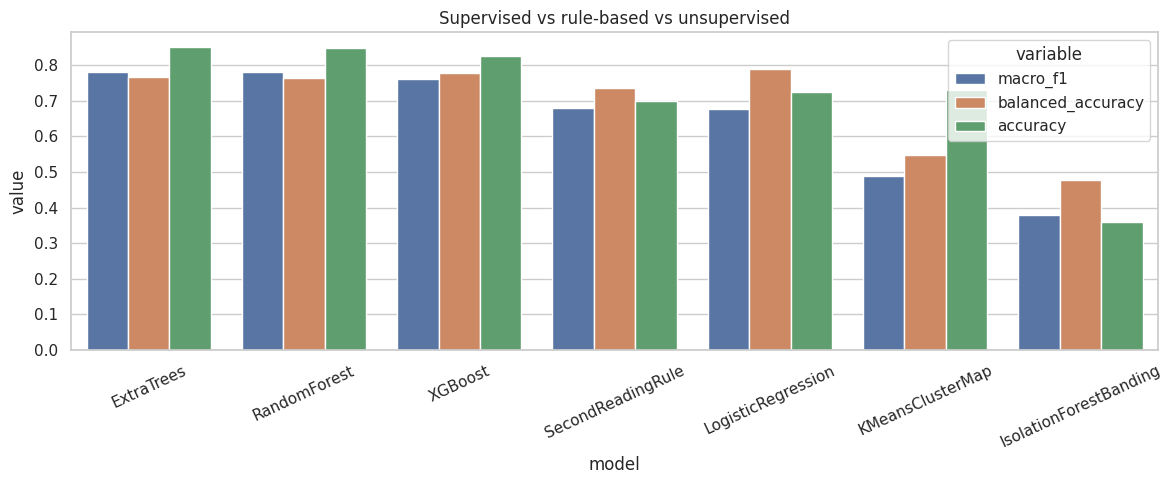

In [32]:
all_compare = pd.concat([
    results_df[["model", "accuracy", "balanced_accuracy", "macro_f1", "weighted_f1", "mcc", "macro_precision", "macro_recall", "roc_auc_ovr_macro"]],
    pd.DataFrame([rule_metrics])[["model", "accuracy", "balanced_accuracy", "macro_f1", "weighted_f1", "mcc", "macro_precision", "macro_recall", "roc_auc_ovr_macro"]],
    unsup_results_df[["model", "accuracy", "balanced_accuracy", "macro_f1", "weighted_f1", "mcc", "macro_precision", "macro_recall", "roc_auc_ovr_macro"]]
], ignore_index=True)

all_compare = all_compare.sort_values(["macro_f1", "balanced_accuracy"], ascending=False)
display(all_compare)

plt.figure(figsize=(12, 5))
sns.barplot(
    data=all_compare.melt(id_vars="model", value_vars=["macro_f1", "balanced_accuracy", "accuracy"]),
    x="model", y="value", hue="variable"
)
plt.xticks(rotation=25)
plt.title("Supervised vs rule-based vs unsupervised")
plt.tight_layout()
plt.savefig("output/model_comparison_multiclass.png", dpi=160, bbox_inches="tight")
plt.show()

In [33]:
if best_model_name == "XGBoost":
    _, final_model, final_prep = fitted_pipelines[best_model_name]
else:
    _, final_pipe = fitted_pipelines[best_model_name]

def build_patient_features(patient):
    sys1, sys2 = patient["sys1"], patient["sys2"]
    dia1, dia2 = patient["dias1"], patient["dias2"]
    pulse1, pulse2 = patient["pulse1"], patient["pulse2"]

    sys12_mean = np.mean([sys1, sys2])
    dia12_mean = np.mean([dia1, dia2])
    pulse12_mean = np.mean([pulse1, pulse2])

    sys12_std = np.std([sys1, sys2], ddof=1) if len([sys1, sys2]) > 1 else 0
    dia12_std = np.std([dia1, dia2], ddof=1) if len([dia1, dia2]) > 1 else 0
    pulse12_std = np.std([pulse1, pulse2], ddof=1) if len([pulse1, pulse2]) > 1 else 0

    age_z = (patient.get("age", age_med) - age_med) / age_sd
    bmi_z = (patient.get("bmi", bmi_med) - bmi_med) / bmi_sd
    std_z = (sys12_std - std_med) / std_sd

    row = {
        "RIDAGEYR": patient.get("age", age_med),
        "is_female": int(str(patient.get("gender", "M")).upper() == "F"),
        "RIDRETH3": patient.get("racecode", 3),
        "INDFMPIR": patient.get("incomepir", 1.5),
        "DMDEDUC2": patient.get("education", 3),
        "BMXBMI": patient.get("bmi", bmi_med),
        "BMXWT": patient.get("weight", np.nan),
        "BMXHT": patient.get("height", np.nan),
        "rx_count": patient.get("rxcount", 0),
        "antihypertensive_flag": int(patient.get("onrecentrx", 0)),
        "BPXOSY1": sys1,
        "BPXOSY2": sys2,
        "BPXODI1": dia1,
        "BPXODI2": dia2,
        "BPXOPLS1": pulse1,
        "BPXOPLS2": pulse2,
        "sys12_mean": sys12_mean,
        "dia12_mean": dia12_mean,
        "pulse12_mean": pulse12_mean,
        "sys12_std": sys12_std,
        "dia12_std": dia12_std,
        "pulse12_std": pulse12_std,
        "sys_trend_21": sys2 - sys1,
        "dia_trend_21": dia2 - dia1,
        "pulse_trend_21": pulse2 - pulse1,
        "pp12": sys12_mean - dia12_mean,
        "map12": (sys12_mean + 2 * dia12_mean) / 3,
        "syscv12": (sys12_std / sys12_mean * 100) if sys12_mean else 0,
        "diacv12": (dia12_std / dia12_mean * 100) if dia12_mean else 0,
        "low_income_flag": int(patient.get("incomepir", 1.5) < 1.3),
        "obesity_cat": pd.cut(
            pd.Series([patient.get("bmi", bmi_med)]),
            bins=[0, 18.5, 25, 30, 35, 100],
            labels=["Underweight", "Normal", "Overweight", "Obese_I", "Obese_II"]
        ).astype(str).iloc[0],
        "morningsurge_proxy": DRYAD_STATS["mean_morning_evening_diff"] * (
            0.40 * np.clip(age_z, -3, 3) +
            0.30 * np.clip(bmi_z, -3, 3) +
            0.30 * np.clip(std_z, -3, 3)
        ),
        "nondipper_risk": (
            0.35 * int(sys12_mean >= 130) +
            0.25 * int(dia12_mean >= 80) +
            0.20 * int(patient.get("racecode", 3) == 4) +
            0.10 * np.clip(age_z, -3, 3) +
            0.10 * (1 - int(patient.get("onrecentrx", 0)))
        )
    }

    row["circadian_dysregulation_index"] = (
        0.5 * row["syscv12"] +
        0.3 * row["diacv12"] +
        0.2 * row["nondipper_risk"]
    )

    out = pd.DataFrame([row])
    for c in X.columns:
        if c not in out.columns:
            out[c] = np.nan
    out = out[X.columns]
    return out

def predict_patient_alert_type(patient):
    Xp = build_patient_features(patient)

    if best_model_name == "XGBoost":
        Xp_prepared = final_prep.transform(Xp)
        prob = final_model.predict_proba(Xp_prepared)[0]
        pred_id = int(np.argmax(prob))
    else:
        prob = final_pipe.predict_proba(Xp)[0]
        pred_id = int(np.argmax(prob))

    return {
        "predicted_alert_type": ID_TO_CLASS[pred_id],
        "class_probabilities": {
            cls: round(float(prob[i]), 4) for i, cls in enumerate(CLASS_ORDER)
        }
    }

demo_patient = {
    "age": 71,
    "gender": "F",
    "racecode": 4,
    "bmi": 35.8,
    "incomepir": 0.8,
    "education": 2,
    "sys1": 170,
    "sys2": 174,
    "dias1": 102,
    "dias2": 106,
    "pulse1": 84,
    "pulse2": 86,
    "onrecentrx": 0,
    "rxcount": 0
}

predict_patient_alert_type(demo_patient)

{'predicted_alert_type': 'Hypertensive',
 'class_probabilities': {'Hypotensive': 0.0014,
  'Normal': 0.004,
  'Hypertensive': 0.9947}}

In [34]:
all_compare.to_csv("output/model_comparison_multiclass.csv", index=False)
results_df.to_csv("output/supervised_results_multiclass.csv", index=False)
unsup_results_df.to_csv("output/unsupervised_results_multiclass.csv", index=False)
df_model.to_csv("output/nhanes_personalized_alert_dataset.csv", index=False)

for model_name, table in per_class_tables.items():
    safe = model_name.lower().replace(" ", "_")
    table.to_csv(f"output/{safe}_per_class_metrics.csv", index=False)

print("Saved outputs to /output")

Saved outputs to /output
